<a href="https://colab.research.google.com/github/DevikaPushpangathan/Medical-Modality-Translation/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single Discriminator**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import os
from PIL import Image

In [ ]:
class CTMRIDataset(Dataset):
    def __init__(self, ct_dir, mri_dir, transform=None):
        self.ct_files = sorted([os.path.join(ct_dir, f) for f in os.listdir(ct_dir) if f.endswith((".png", ".jpg", ".jpeg"))])
        self.mri_files = sorted([os.path.join(mri_dir, f) for f in os.listdir(mri_dir) if f.endswith((".png", ".jpg", ".jpeg"))])
        assert len(self.ct_files) == len(self.mri_files), "CT and MRI dataset sizes do not match!"
        self.transform = transform

    def __len__(self):
        return len(self.ct_files)

    def __getitem__(self, idx):
        ct_img = Image.open(self.ct_files[idx]).convert("L")   # Grayscale
        mri_img = Image.open(self.mri_files[idx]).convert("L") # Grayscale

        if self.transform:
            ct_img = self.transform(ct_img)
            mri_img = self.transform(mri_img)

        return ct_img, mri_img

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),       # Resize for faster training
    transforms.ToTensor(),               # Convert to tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1,1] for GAN
])

In [ ]:
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=64):
        super(UNetGenerator, self).__init__()
        self.encoder1 = self.conv_block(in_channels, features)
        self.encoder2 = self.conv_block(features, features*2)
        self.encoder3 = self.conv_block(features*2, features*4)
        self.encoder4 = self.conv_block(features*4, features*8)
        self.bottleneck = self.conv_block(features*8, features*16)
        self.up4 = self.up_conv(features*16, features*8)
        self.up3 = self.up_conv(features*8, features*4)
        self.up2 = self.up_conv(features*4, features*2)
        self.up1 = self.up_conv(features*2, features)
        self.final = nn.Conv2d(features, out_channels, kernel_size=1)
        self.tanh = nn.Tanh()

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def up_conv(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
      e1 = self.encoder1(x)
      e2 = self.encoder2(e1)
      e3 = self.encoder3(e2)
      e4 = self.encoder4(e3)
      b = self.bottleneck(e4)
      d4 = self.up4(b) + e4
      d3 = self.up3(d4) + e3
      d2 = self.up2(d3) + e2
      d1 = self.up1(d2) + e1

      out = self.final(d1)
      out = nn.functional.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
      return self.tanh(out)



In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64):
        super(PatchDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features*2, 4, 2, 1),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features*2, features*4, 4, 2, 1),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features*4, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_dir = "/content/extracted_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Unzipped successfully to:", extract_dir)

✅ Unzipped successfully to: /content/extracted_data


In [ ]:
import os

path = "/content/extracted_data/Dataset/images/trainB"
count = sum(len(files) for _, _, files in os.walk(path))
print(f"Total number of files: {count}")

Total number of files: 1742


In [ ]:
source_dir = "/content/extracted_data/Dataset/images/trainA"
target_dir = "/content/extracted_data/Dataset/images/trainB"
dataset = CTMRIDataset(source_dir, target_dir, transform=transform)

loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
import os
import torchvision.utils as vutils
os.makedirs("samples", exist_ok=True)

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np


def evaluate_generated_images(fake_imgs, real_imgs):
    """
    Compute average SSIM and PSNR between fake and real MRI images in a batch.
    """
    fake_imgs = fake_imgs.detach().cpu().numpy()
    real_imgs = real_imgs.detach().cpu().numpy()

    batch_ssim, batch_psnr = 0, 0
    for i in range(fake_imgs.shape[0]):
        # Convert to 2D grayscale image (since both CT/MRI are single-channel)
        f = np.squeeze(fake_imgs[i])
        r = np.squeeze(real_imgs[i])

        # Normalize to 0-1 range for metric calculation
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        r = (r - r.min()) / (r.max() - r.min() + 1e-8)

        # Compute SSIM and PSNR
        batch_ssim += ssim(f, r, data_range=1)
        batch_psnr += psnr(r, f, data_range=1)

    return batch_ssim / fake_imgs.shape[0], batch_psnr / fake_imgs.shape[0]


In [ ]:
num_epochs = 50
for epoch in range(num_epochs):
    for i, (src, tgt) in enumerate(loader):
        src, tgt = src.to(device), tgt.to(device)
        #discriminator training
        optimizer_D.zero_grad()
        fake_tgt = G(src)

        real_input = torch.cat([src, tgt], dim=1)
        fake_input = torch.cat([src, fake_tgt.detach()], dim=1)

        pred_real = D(real_input)
        pred_fake = D(fake_input)

        real_label = torch.ones_like(pred_real)
        fake_label = torch.zeros_like(pred_fake)

        loss_D_real = criterion_GAN(pred_real, real_label)
        loss_D_fake = criterion_GAN(pred_fake, fake_label)
        loss_D = (loss_D_real + loss_D_fake) * 0.5

        loss_D.backward()
        optimizer_D.step()


        # Generator training

        optimizer_G.zero_grad()
        fake_input = torch.cat([src, fake_tgt], dim=1)
        pred_fake = D(fake_input)

        loss_G_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
        loss_G_L1 = criterion_L1(fake_tgt, tgt) * 100
        loss_G = loss_G_GAN + loss_G_L1

        loss_G.backward()
        optimizer_G.step()

        if i % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i}/{len(loader)}], "
                  f"D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")
        if i % 100 == 0:
          with torch.no_grad():
            ssim_score, psnr_score = evaluate_generated_images(fake_tgt, tgt)
          print(f"   >> SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB")


    if epoch % 5 == 0:
        vutils.save_image(
            torch.cat([src, fake_tgt, tgt], dim=0),
            f"samples/epoch_{epoch+1}.png",
            normalize=True,
            nrow=src.size(0)
        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/50], Step [0/436], D Loss: 0.7056, G Loss: 135.9867
   >> SSIM: 0.0256, PSNR: 4.51 dB
Epoch [1/50], Step [10/436], D Loss: 0.5176, G Loss: 58.3024
Epoch [1/50], Step [20/436], D Loss: 0.3363, G Loss: 54.3291
Epoch [1/50], Step [30/436], D Loss: 0.2388, G Loss: 49.8901
Epoch [1/50], Step [40/436], D Loss: 0.3079, G Loss: 57.4400
Epoch [1/50], Step [50/436], D Loss: 0.1992, G Loss: 44.5662
Epoch [1/50], Step [60/436], D Loss: 0.2150, G Loss: 41.8709
Epoch [1/50], Step [70/436], D Loss: 0.1823, G Loss: 31.2977
Epoch [1/50], Step [80/436], D Loss: 0.2733, G Loss: 25.5156
Epoch [1/50], Step [90/436], D Loss: 0.1457, G Loss: 25.1010
Epoch [1/50], Step [100/436], D Loss: 0.5680, G Loss: 32.5050
   >> SSIM: 0.1561, PSNR: 13.51 dB
Epoch [1/50], Step [110/436], D Loss: 0.1686, G Loss: 32.4342
Epoch [1/50], Step [120/436], D Loss: 0.3175, G Loss: 30.2901
Epoch [1/50], Step [130/436], D Loss: 0.4089, G Loss: 36.2681
Epoch [1/50], Step [140/436], D Loss: 0.4247, G Loss: 29.6877
Epoch [1/50

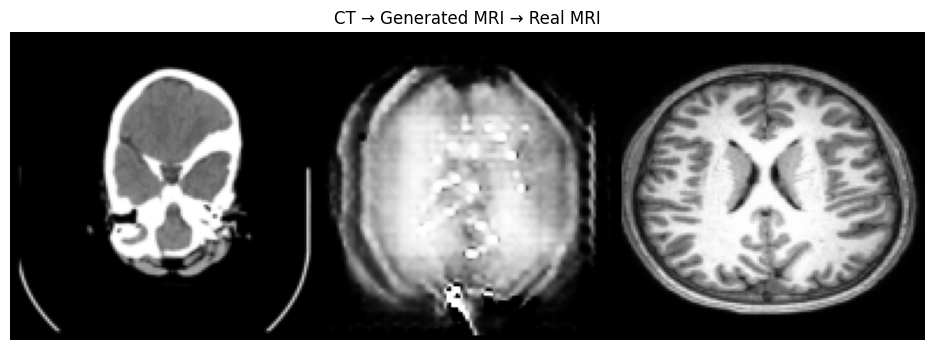

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

fake_tgt = G(src.to(device))
grid = make_grid([src[0], fake_tgt[0], tgt[0]], nrow=3, normalize=True)
plt.figure(figsize=(12,4))
plt.imshow(grid.permute(1,2,0).cpu())
plt.title("CT → Generated MRI → Real MRI")
plt.axis('off')
plt.show()



=== Loaded Metrics Data ===

    Epoch  Avg D Loss  Avg G Loss  Avg SSIM  Avg PSNR (dB)
0     1.0    0.302833   49.631867  0.162183      11.791667
1     2.0    0.247900   30.802560  0.229860      13.460000
2     3.0    0.227560   35.790520  0.193540      12.548000
3     4.0    0.271720   28.053800  0.241300      13.442000
4     5.0    0.249800   31.166380  0.230940      13.936000
5     6.0    0.182280   30.602300  0.237280      13.656000
6     7.0    0.153700   30.279320  0.232500      13.652000
7     8.0    0.282320   30.942040  0.239360      12.768000
8     9.0    0.151840   30.484820  0.236440      13.004000
9    10.0    0.278420   28.445180  0.232860      13.134000
10   11.0    0.044780   32.129540  0.242540      13.188000
11   12.0    0.150400   30.309640  0.243740      13.056000
12   13.0    0.082160   34.396060  0.269140      13.040000
13   14.0    0.044640   32.298280  0.232400      13.460000
14   15.0    0.035840   31.900600  0.251540      13.158000
15   16.0    0.027740   31

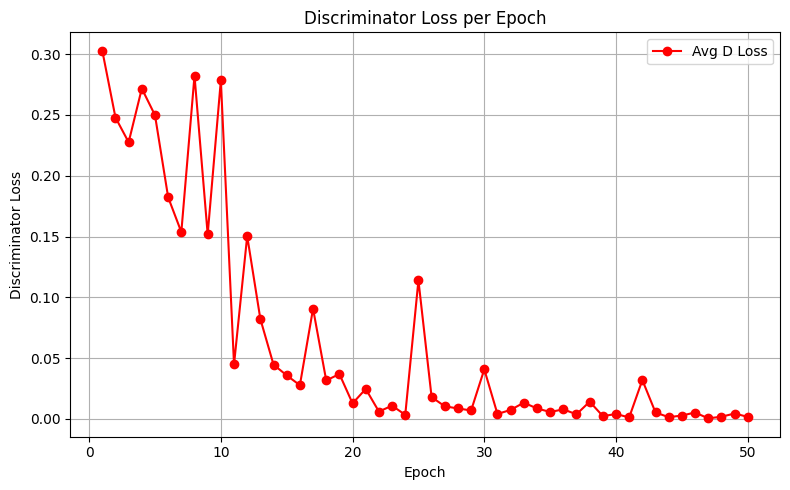

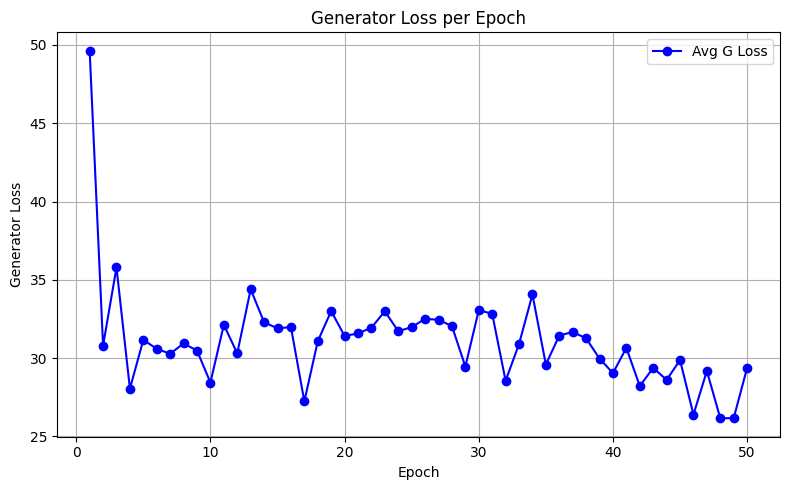

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'epoch_average_metrics.csv'
df = pd.read_csv(file_path)

print("\n=== Loaded Metrics Data ===\n")
print(df)

#  Plot Discriminator Loss
plt.figure(figsize=(8, 5))
plt.plot(df['Epoch'], df['Avg D Loss'], 'r-o', label='Avg D Loss')
plt.title('Discriminator Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Discriminator Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Generator Loss separately
plt.figure(figsize=(8, 5))
plt.plot(df['Epoch'], df['Avg G Loss'], 'b-o', label='Avg G Loss')
plt.title('Generator Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Generator Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# **Dual-Discriminator**

> Add blockquote



In [ ]:
import os
import random
from glob import glob
from tqdm import tqdm

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from skimage.metrics import structural_similarity as sk_ssim
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
print("Device:", device)

Device: cpu


In [ ]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_dir = "/content/extracted_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipped successfully to:", extract_dir)


ZIP_EXTRACT_DIR = "/content/extracted_data"
SOURCE_DIR = os.path.join(ZIP_EXTRACT_DIR, "Dataset/images/trainA")
TARGET_DIR = os.path.join(ZIP_EXTRACT_DIR, "Dataset/images/trainB")
OUT_DIR = "training_output_cpu"
os.makedirs(OUT_DIR, exist_ok=True)
SAMPLES_DIR = os.path.join(OUT_DIR, "samples"); os.makedirs(SAMPLES_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(OUT_DIR, "checkpoints"); os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Unzipped successfully to: /content/extracted_data


In [ ]:
ZIP_EXTRACT_DIR = "/content/extracted_data"
SOURCE_DIR = os.path.join(ZIP_EXTRACT_DIR, "Dataset/images/trainA")
TARGET_DIR = os.path.join(ZIP_EXTRACT_DIR, "Dataset/images/trainB")
OUT_DIR = "training_output_cpu"
os.makedirs(OUT_DIR, exist_ok=True)
SAMPLES_DIR = os.path.join(OUT_DIR, "samples"); os.makedirs(SAMPLES_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(OUT_DIR, "checkpoints"); os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 1
NUM_WORKERS = 0
NUM_EPOCHS = 50
LR = 2e-4
BETA1, BETA2 = 0.5, 0.999
L1_LAMBDA = 100.0
SAVE_SAMPLES_EVERY_N_EPOCHS = 1

In [ ]:
class CTMRIDataset(Dataset):
    def __init__(self, ct_dir, mri_dir, transform=None):
        ct_list = sorted([p for p in glob(os.path.join(ct_dir, "*")) if p.lower().endswith((".png", ".jpg", ".jpeg"))])
        mri_list = sorted([p for p in glob(os.path.join(mri_dir, "*")) if p.lower().endswith((".png", ".jpg", ".jpeg"))])
        assert len(ct_list) == len(mri_list), f"CT/MRI count mismatch: {len(ct_list)} vs {len(mri_list)}"
        self.ct_files = ct_list
        self.mri_files = mri_list
        self.transform = transform

    def __len__(self):
        return len(self.ct_files)

    def __getitem__(self, idx):
        ct = Image.open(self.ct_files[idx]).convert("L")
        mri = Image.open(self.mri_files[idx]).convert("L")
        if self.transform:
            ct = self.transform(ct)
            mri = self.transform(mri)
        return ct, mri

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
import os
from glob import glob
from PIL import Image


trainB_dir = "/content/extracted_data/Dataset/images/trainB"
image_paths = sorted(glob(os.path.join(trainB_dir, "*")))

print(f"Total images found in trainB: {len(image_paths)}")

indices_to_check = [1743, 1744]
for idx in indices_to_check:
    if idx <= len(image_paths):
        print(f"\nImage #{idx}: {image_paths[idx-1]}")
        try:
            img = Image.open(image_paths[idx-1])
            img.show()
        except Exception as e:
            print(f" Cannot open image #{idx}: {e}")
    else:
        print(f" Image index {idx} out of range")


delete = input("\nDelete these images? (y/n): ").strip().lower()
if delete == "y":
    for idx in indices_to_check:
        if idx <= len(image_paths):
            path = image_paths[idx-1]
            if os.path.exists(path):
                os.remove(path)
                print(f"🗑️ Deleted: {path}")
            else:
                print(f" File not found: {path}")
else:
    print(" Deletion canceled.")


Total images found in trainB: 1744

Image #1743: /content/extracted_data/Dataset/images/trainB/mri996.jpg

Image #1744: /content/extracted_data/Dataset/images/trainB/mri997.jpg

Delete these images? (y/n): y
🗑️ Deleted: /content/extracted_data/Dataset/images/trainB/mri996.jpg
🗑️ Deleted: /content/extracted_data/Dataset/images/trainB/mri997.jpg


In [ ]:
dataset = CTMRIDataset(SOURCE_DIR, TARGET_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)


In [ ]:
def spectral_norm(module):
    return nn.utils.spectral_norm(module)

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=64):
        super().__init__()
        self.down1 = self.conv_block(in_channels, features, batchnorm=False)
        self.down2 = self.conv_block(features, features*2)
        self.down3 = self.conv_block(features*2, features*4)
        self.down4 = self.conv_block(features*4, features*8)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        self.up4 = self.up_conv(features*16, features*8)
        self.up3 = self.up_conv(features*8*2, features*4)
        self.up2 = self.up_conv(features*4*2, features*2)
        self.up1 = self.up_conv(features*2*2, features)
        self.final = nn.Conv2d(features*2, out_channels, kernel_size=1)
        self.tanh = nn.Tanh()

    def conv_block(self, in_c, out_c, batchnorm=True):
        layers = [nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1)]
        if batchnorm:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def up_conv(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        b = self.bottleneck(d4)
        u4 = self.up4(b); u4 = torch.cat([u4, d4], dim=1)
        u3 = self.up3(u4); u3 = torch.cat([u3, d3], dim=1)
        u2 = self.up2(u3); u2 = torch.cat([u2, d2], dim=1)
        u1 = self.up1(u2); u1 = torch.cat([u1, d1], dim=1)
        out = self.final(u1)
        out = nn.functional.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
        return self.tanh(out)


In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64):
        super().__init__()
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, features, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features, features*2, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features*2, features*4, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features*4, 1, 4, 1, 1)),
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
class DeepDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64):
        super().__init__()
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, features, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features, features*2, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features*2, features*4, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features*4, features*8, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(features*8, 1, 4, 1, 1))
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
G = UNetGenerator(in_channels=1, out_channels=1).to(device)
D1 = PatchDiscriminator(in_channels=2).to(device)
D2 = DeepDiscriminator(in_channels=2).to(device)

In [ ]:
# Losses & Optimizer
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D1 = optim.Adam(D1.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D2 = optim.Adam(D2.parameters(), lr=LR, betas=(BETA1, BETA2))


In [ ]:

def compute_ssim_psnr_batch(fake, real):
    fake_np = fake.detach().cpu().numpy()
    real_np = real.detach().cpu().numpy()
    batch_ssim, batch_psnr = 0.0, 0.0
    n = fake_np.shape[0]
    for i in range(n):
        f = np.squeeze(fake_np[i]); r = np.squeeze(real_np[i])
        f = (f - f.min())/(f.max() - f.min() + 1e-8)
        r = (r - r.min())/(r.max() - r.min() + 1e-8)
        batch_ssim += sk_ssim(r, f, data_range=1)
        batch_psnr += sk_psnr(r, f, data_range=1)
    return batch_ssim / max(1,n), batch_psnr / max(1,n)


In [ ]:
def save_samples(epoch, src, fake, tgt, out_dir=SAMPLES_DIR, nrow=None):
    src, fake, tgt = src.detach().cpu(), fake.detach().cpu(), tgt.detach().cpu()
    def denorm(x): return (x * 0.5) + 0.5
    grid = torch.cat([denorm(src), denorm(fake), denorm(tgt)], dim=0)
    nrow = nrow or src.size(0)
    vutils.save_image(grid, os.path.join(out_dir, f"epoch_{epoch:04d}.png"), normalize=False, nrow=nrow)


In [ ]:
def plot_and_save(metrics_df, out_dir=OUT_DIR):
    px = os.path.join
    plt.figure(figsize=(8,5))
    plt.plot(metrics_df['epoch'], metrics_df['G_total'], label='G_total')
    plt.plot(metrics_df['epoch'], metrics_df['D_total'], label='D_total')
    plt.plot(metrics_df['epoch'], metrics_df['L1'], label='L1*lambda')
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")
    plt.grid(True); plt.tight_layout()
    plt.savefig(px(out_dir, "loss_curves_cpu.png")); plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(metrics_df['epoch'], metrics_df['SSIM'], label='SSIM')
    plt.plot(metrics_df['epoch'], metrics_df['PSNR'], label='PSNR')
    plt.xlabel("Epoch"); plt.ylabel("Metric"); plt.legend(); plt.title("SSIM & PSNR")
    plt.grid(True); plt.tight_layout()
    plt.savefig(px(out_dir, "ssim_psnr_cpu.png")); plt.close()



In [ ]:
metrics_columns = [
    'epoch',
    'G_total', 'G_gan_D1', 'G_gan_D2', 'L1',
    'D_total', 'D1_loss', 'D2_loss',
    'SSIM', 'PSNR'
]
metrics_log = []

best_val_l1 = float('inf')
metrics_csv_path = os.path.join(OUT_DIR, "metrics_log_cpu.csv")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DRIVE_OUT_DIR = '/content/drive/MyDrive/training_output_pix2pix'
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

OUT_DIR = DRIVE_OUT_DIR
SAMPLES_DIR = os.path.join(OUT_DIR, "samples"); os.makedirs(SAMPLES_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(OUT_DIR, "checkpoints"); os.makedirs(CHECKPOINT_DIR, exist_ok=True)

metrics_csv_path = os.path.join(OUT_DIR, "metrics_log_cpu.csv")

print(f"All training outputs will now be saved to: {OUT_DIR}")
print(f"Samples will be saved to: {SAMPLES_DIR}")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")
print(f"Metrics log will be saved to: {metrics_csv_path}")

All training outputs will now be saved to: /content/drive/MyDrive/training_output_pix2pix
Samples will be saved to: /content/drive/MyDrive/training_output_pix2pix/samples
Checkpoints will be saved to: /content/drive/MyDrive/training_output_pix2pix/checkpoints
Metrics log will be saved to: /content/drive/MyDrive/training_output_pix2pix/metrics_log_cpu.csv


In [ ]:

global_step = 0
for epoch in range(1, NUM_EPOCHS+1):
    G.train(); D1.train(); D2.train()
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    epoch_l1 = 0.0
    epoch_ssim = 0.0
    epoch_psnr = 0.0
    n_batches = 0

    loop = tqdm(loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for i, (src, tgt) in enumerate(loop):
        src = src.to(device); tgt = tgt.to(device)
        batch_size = src.size(0)
        n_batches += 1
        global_step += 1

        fake = G(src)

        # D1 update
        optimizer_D1.zero_grad()
        real_input = torch.cat([src, tgt], dim=1)
        fake_input = torch.cat([src, fake.detach()], dim=1)
        out_real_D1 = D1(real_input); out_fake_D1 = D1(fake_input)
        real_label = torch.ones_like(out_real_D1, device=device); fake_label = torch.zeros_like(out_fake_D1, device=device)
        loss_D1 = 0.5 * (criterion_GAN(out_real_D1, real_label) + criterion_GAN(out_fake_D1, fake_label))
        loss_D1.backward(); optimizer_D1.step()

        # D2 update
        optimizer_D2.zero_grad()
        out_real_D2 = D2(real_input); out_fake_D2 = D2(fake_input)
        real_label2 = torch.ones_like(out_real_D2, device=device); fake_label2 = torch.zeros_like(out_fake_D2, device=device)
        loss_D2 = 0.5 * (criterion_GAN(out_real_D2, real_label2) + criterion_GAN(out_fake_D2, fake_label2))
        loss_D2.backward(); optimizer_D2.step()

        loss_D_total = 0.5 * (loss_D1 + loss_D2)

        # Generator update
        optimizer_G.zero_grad()
        fake_input_for_G = torch.cat([src, fake], dim=1)
        pred_D1 = D1(fake_input_for_G); pred_D2 = D2(fake_input_for_G)
        target_real_for_G1 = torch.ones_like(pred_D1, device=device); target_real_for_G2 = torch.ones_like(pred_D2, device=device)
        loss_G_gan_D1 = criterion_GAN(pred_D1, target_real_for_G1)
        loss_G_gan_D2 = criterion_GAN(pred_D2, target_real_for_G2)
        loss_G_gan = 0.5 * (loss_G_gan_D1 + loss_G_gan_D2)
        loss_G_l1 = criterion_L1(fake, tgt) * L1_LAMBDA
        loss_G = loss_G_gan + loss_G_l1
        loss_G.backward(); optimizer_G.step()

        # Metrics
        ssim_b, psnr_b = compute_ssim_psnr_batch(fake, tgt)

        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D_total.item()
        epoch_l1 += loss_G_l1.item()
        epoch_ssim += ssim_b
        epoch_psnr += psnr_b

        loop.set_postfix({
            'G_total': f"{loss_G.item():.4f}",
            'D_total': f"{loss_D_total.item():.4f}",
            'L1': f"{loss_G_l1.item():.4f}",
            'SSIM': f"{ssim_b:.4f}",
            'PSNR': f"{psnr_b:.2f}"
        })

        if global_step % 100 == 0:
            save_samples(epoch, src, fake, tgt, out_dir=SAMPLES_DIR, nrow=src.size(0))


    n = max(1, n_batches)
    epoch_G_loss_avg = epoch_G_loss / n
    epoch_D_loss_avg = epoch_D_loss / n
    epoch_l1_avg = epoch_l1 / n
    epoch_ssim_avg = epoch_ssim / n
    epoch_psnr_avg = epoch_psnr / n

    metrics_row = {
        'epoch': epoch,
        'G_total': epoch_G_loss_avg,
        'G_gan_D1': None,
        'G_gan_D2': None,
        'L1': epoch_l1_avg,
        'D_total': epoch_D_loss_avg,
        'D1_loss': None,
        'D2_loss': None,
        'SSIM': epoch_ssim_avg,
        'PSNR': epoch_psnr_avg
    }
    metrics_log.append(metrics_row)
    df_metrics = pd.DataFrame(metrics_log)
    df_metrics.to_csv(metrics_csv_path, index=False)


    with torch.no_grad():
        save_samples(epoch, src, fake, tgt, out_dir=SAMPLES_DIR, nrow=src.size(0))

    ckpt = {
        'epoch': epoch,
        'G_state': G.state_dict(),
        'D1_state': D1.state_dict(),
        'D2_state': D2.state_dict(),
        'opt_G': optimizer_G.state_dict(),
        'opt_D1': optimizer_D1.state_dict(),
        'opt_D2': optimizer_D2.state_dict()
    }
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch:04d}.pth"))
    if epoch_l1_avg < best_val_l1:
        best_val_l1 = epoch_l1_avg
        torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"best_checkpoint_epoch_{epoch:04d}.pth"))
        print(f"Saved new best model by L1: epoch {epoch}, L1 {best_val_l1:.4f}")

    plot_and_save(df_metrics, out_dir=OUT_DIR)
    print(f"Epoch {epoch:03d} summary: G_loss={epoch_G_loss_avg:.4f}, D_loss={epoch_D_loss_avg:.4f}, L1={epoch_l1_avg:.4f}, SSIM={epoch_ssim_avg:.4f}, PSNR={epoch_psnr_avg:.2f} dB")

print("Training finished. Metrics saved to:", metrics_csv_path)
print("Checkpoints saved to:", CHECKPOINT_DIR)
print("Sample images saved to:", SAMPLES_DIR)

Saved new best model by L1: epoch 1, L1 24.7162
Epoch 001 summary: G_loss=26.3540, D_loss=0.3619, L1=24.7162, SSIM=0.2338, PSNR=11.72 dB


Saved new best model by L1: epoch 2, L1 24.6930
Epoch 002 summary: G_loss=26.5129, D_loss=0.3148, L1=24.6930, SSIM=0.2712, PSNR=14.14 dB


Epoch 003 summary: G_loss=26.7266, D_loss=0.3126, L1=24.9078, SSIM=0.2717, PSNR=14.06 dB


Epoch 004 summary: G_loss=26.8246, D_loss=0.2952, L1=24.9417, SSIM=0.2688, PSNR=14.03 dB


Epoch 005 summary: G_loss=26.9688, D_loss=0.2817, L1=25.0093, SSIM=0.2651, PSNR=13.97 dB


...

Saved new best model by L1: epoch 17, L1 20.0448
Epoch 017 summary: G_loss=21.9145, D_loss=0.3029, L1=20.0448, SSIM=0.3117, PSNR=15.03 dB


Saved new best model by L1: epoch 18, L1 19.0837
Epoch 018 summary: G_loss=20.9292, D_loss=0.3085, L1=19.0837, SSIM=0.3289, PSNR=15.33 dB


Saved new best model by L1: epoch 19, L1 18.1745
Epoch 019 summary: G_loss=19.9931, D_loss=0.3121, L1=18.1745, SSIM=0.3494, PSNR=15.65 dB


Saved new best model by L1: epoch 20, L1 17.2291
Epoch 020 summary: G_loss=19.0257, D_loss=0.3140, L1=17.2291, SSIM=0.3705, PSNR=16.00 dB


Epoch 21/50:  27%|██▋       | 465/1742 [11:35<31:11,  1.47s/it, G_total=18.8695, D_total=0.2674, L1=16.6757, SSIM=0.2684, PSNR=16.57]

In [ ]:
import os

output_dir = '/content/drive/MyDrive/training_output_pix2pix'
checkpoints_dir = os.path.join(output_dir, "checkpoints")
samples_dir = os.path.join(output_dir, "samples")
metrics_csv_path = os.path.join(output_dir, "metrics_log_cpu.csv")

print(f"Contents of '{checkpoints_dir}':")
if os.path.exists(checkpoints_dir):
    for f in os.listdir(checkpoints_dir):
        print(f"- {f}")
else:
    print("  (Directory not found)")

print(f"\nContents of '{samples_dir}':")
if os.path.exists(samples_dir):
    for f in os.listdir(samples_dir):
        print(f"- {f}")
else:
    print("  (Directory not found)")

print(f"\nMetrics CSV file exists: {os.path.exists(metrics_csv_path)}")

Contents of '/content/drive/MyDrive/training_output_pix2pix/checkpoints':
- checkpoint_epoch_0001.pth
- best_checkpoint_epoch_0001.pth
- checkpoint_epoch_0002.pth
- best_checkpoint_epoch_0002.pth
- checkpoint_epoch_0003.pth
- checkpoint_epoch_0004.pth
- checkpoint_epoch_0005.pth
- checkpoint_epoch_0006.pth
- checkpoint_epoch_0007.pth
- checkpoint_epoch_0008.pth
- checkpoint_epoch_0009.pth
- checkpoint_epoch_0010.pth
- checkpoint_epoch_0011.pth
- checkpoint_epoch_0012.pth
- checkpoint_epoch_0013.pth
- checkpoint_epoch_0014.pth
- checkpoint_epoch_0015.pth
- checkpoint_epoch_0016.pth
- checkpoint_epoch_0017.pth
- checkpoint_epoch_0018.pth
- checkpoint_epoch_0019.pth
- checkpoint_epoch_0020.pth
- checkpoint_epoch_0021.pth
- checkpoint_epoch_0022.pth

Contents of '/content/drive/MyDrive/training_output_pix2pix/samples':
- epoch_0001.png
- epoch_0002.png
- epoch_0003.png
- epoch_0004.png
- epoch_0005.png
- epoch_0006.png
- epoch_0007.png
- epoch_0008.png
- epoch_0009.png
- epoch_0010.png
- e

In [ ]:
import os, re
import torch
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"


NUM_EPOCHS = 50
CHECKPOINT_DIR = "/content/drive/MyDrive/training_output_pix2pix/checkpoints"
SAMPLES_DIR = "/content/drive/MyDrive/training_output_pix2pix/samples"
metrics_csv_path = "/content/drive/MyDrive/training_output_pix2pix/metrics_log_cpu.csv"


ckpts = [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("checkpoint_epoch_")]
if len(ckpts) == 0:
    print("⚠ No checkpoint found. Starting from epoch 1.")
    last_epoch = 0
else:
    epochs = [int(re.findall(r"checkpoint_epoch_(\d+).pth", f)[0]) for f in ckpts]
    last_epoch = max(epochs)

print(f" Latest checkpoint detected: epoch {last_epoch}")

start_epoch = last_epoch + 1
checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{last_epoch:04d}.pth")

global_step = 0

if last_epoch > 0 and os.path.exists(checkpoint_path):
    print(f"🔄 Loading checkpoint: {checkpoint_path}")

    ckpt = torch.load(checkpoint_path, map_location=device)

    G.load_state_dict(ckpt["G_state"])
    D1.load_state_dict(ckpt["D1_state"])
    D2.load_state_dict(ckpt["D2_state"])

    optimizer_G.load_state_dict(ckpt["opt_G"])
    optimizer_D1.load_state_dict(ckpt["opt_D1"])
    optimizer_D2.load_state_dict(ckpt["opt_D2"])

    if "loader" in globals():
        global_step = last_epoch * len(loader)

    print(f" Resumed training from epoch {start_epoch}, global_step={global_step}")
else:
    print("Starting fresh training.")

if os.path.exists(metrics_csv_path):
    print("Loading previous metrics...")
    df_metrics = pd.read_csv(metrics_csv_path)
    metrics_log = df_metrics.to_dict(orient="records")
else:
    print(" No metrics file found. Creating new.")
    metrics_log = []


📌 Latest checkpoint detected: epoch 22
🔄 Loading checkpoint: /content/drive/MyDrive/training_output_pix2pix/checkpoints/checkpoint_epoch_0022.pth
✅ Resumed training from epoch 23, global_step=38324
📊 Loading previous metrics...


In [ ]:
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    G.train(); D1.train(); D2.train()

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    epoch_l1 = 0.0
    epoch_ssim = 0.0
    epoch_psnr = 0.0
    n_batches = 0

    loop = tqdm(loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for i, (src, tgt) in enumerate(loop):
        src = src.to(device)
        tgt = tgt.to(device)

        batch_size = src.size(0)
        n_batches += 1
        global_step += 1


        fake = G(src)


        optimizer_D1.zero_grad()
        real_input = torch.cat([src, tgt], dim=1)
        fake_input = torch.cat([src, fake.detach()], dim=1)

        out_real_D1 = D1(real_input)
        out_fake_D1 = D1(fake_input)

        real_label = torch.ones_like(out_real_D1)
        fake_label = torch.zeros_like(out_fake_D1)

        loss_D1 = 0.5 * (
            criterion_GAN(out_real_D1, real_label) +
            criterion_GAN(out_fake_D1, fake_label)
        )
        loss_D1.backward()
        optimizer_D1.step()


        optimizer_D2.zero_grad()

        out_real_D2 = D2(real_input)
        out_fake_D2 = D2(fake_input)

        real_label2 = torch.ones_like(out_real_D2)
        fake_label2 = torch.zeros_like(out_fake_D2)

        loss_D2 = 0.5 * (
            criterion_GAN(out_real_D2, real_label2) +
            criterion_GAN(out_fake_D2, fake_label2)
        )
        loss_D2.backward()
        optimizer_D2.step()

        loss_D_total = 0.5 * (loss_D1 + loss_D2)

        optimizer_G.zero_grad()

        fake_input_G = torch.cat([src, fake], dim=1)
        pred_D1 = D1(fake_input_G)
        pred_D2 = D2(fake_input_G)

        target_real1 = torch.ones_like(pred_D1)
        target_real2 = torch.ones_like(pred_D2)

        loss_G_gan = 0.5 * (
            criterion_GAN(pred_D1, target_real1) +
            criterion_GAN(pred_D2, target_real2)
        )

        loss_G_l1 = criterion_L1(fake, tgt) * L1_LAMBDA
        loss_G = loss_G_gan + loss_G_l1

        loss_G.backward()
        optimizer_G.step()


        ssim_b, psnr_b = compute_ssim_psnr_batch(fake, tgt)

        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D_total.item()
        epoch_l1 += loss_G_l1.item()
        epoch_ssim += ssim_b
        epoch_psnr += psnr_b

        loop.set_postfix({
            'G_total': f"{loss_G.item():.4f}",
            'D_total': f"{loss_D_total.item():.4f}",
            'L1': f"{loss_G_l1.item():.4f}",
            'SSIM': f"{ssim_b:.4f}",
            'PSNR': f"{psnr_b:.2f}"
        })

        if global_step % 100 == 0:
            save_samples(epoch, src, fake, tgt, out_dir=SAMPLES_DIR)

    n = max(1, n_batches)
    metrics_row = {
        'epoch': epoch,
        'G_total': epoch_G_loss / n,
        'L1': epoch_l1 / n,
        'D_total': epoch_D_loss / n,
        'SSIM': epoch_ssim / n,
        'PSNR': epoch_psnr / n,
    }
    metrics_log.append(metrics_row)

    df_metrics = pd.DataFrame(metrics_log)
    df_metrics.to_csv(metrics_csv_path, index=False)

    with torch.no_grad():
        save_samples(epoch, src, fake, tgt, out_dir=SAMPLES_DIR)


    ckpt = {
        "epoch": epoch,
        "G_state": G.state_dict(),
        "D1_state": D1.state_dict(),
        "D2_state": D2.state_dict(),
        "opt_G": optimizer_G.state_dict(),
        "opt_D1": optimizer_D1.state_dict(),
        "opt_D2": optimizer_D2.state_dict(),
    }

    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch:04d}.pth"))

    print(f"Epoch {epoch} completed.")


Epoch 23 completed.


Epoch 24 completed.


Epoch 25 completed.


Epoch 26 completed.


Epoch 27 completed.


...

Epoch 39 completed.


Epoch 40 completed.


Epoch 41 completed.


Epoch 42 completed.


Epoch 43/50:   6%|▌         | 96/1742 [02:10<42:15,  1.54s/it, G_total=12.8567, D_total=0.2441, L1=10.9648, SSIM=0.7588, PSNR=19.24]

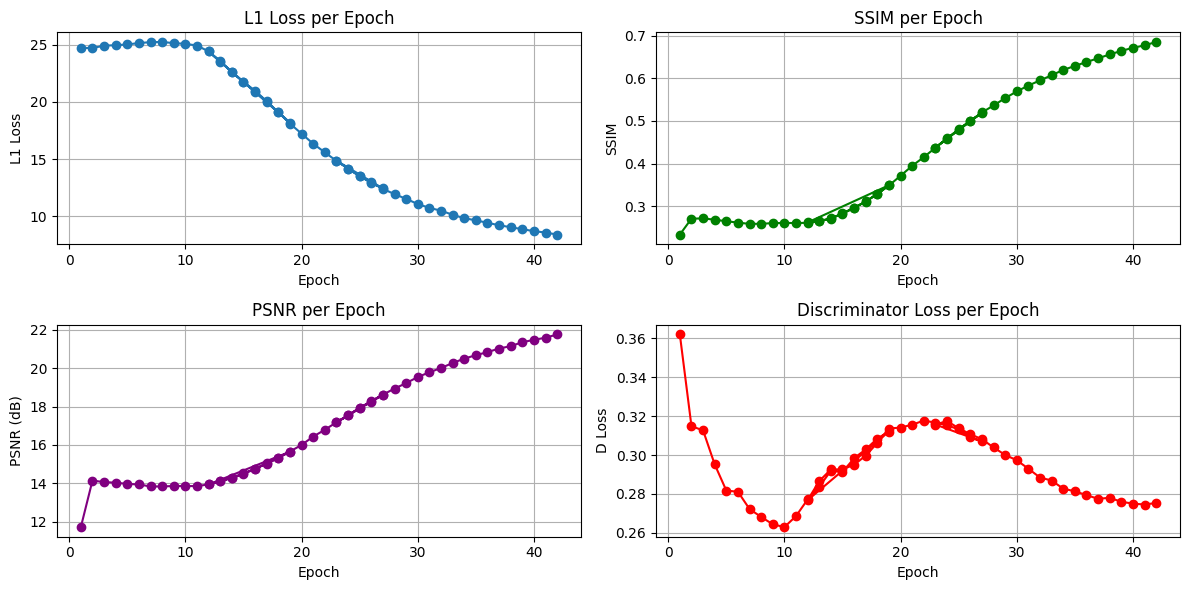

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd



df = pd.read_csv("/content/drive/MyDrive/training_output_pix2pix/metrics_log_cpu.csv")

plt.figure(figsize=(12, 6))

# Plot L1 loss
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["L1"], marker='o')
plt.title("L1 Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.grid(True)

# Plot SSIM
plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["SSIM"], color='green', marker='o')
plt.title("SSIM per Epoch")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.grid(True)

# Plot PSNR
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["PSNR"], color='purple', marker='o')
plt.title("PSNR per Epoch")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.grid(True)

# Plot D loss
plt.subplot(2, 2, 4)
plt.plot(df["epoch"], df["D_total"], color='red', marker='o')
plt.title("Discriminator Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("D Loss")
plt.grid(True)

plt.tight_layout()
plt.show()


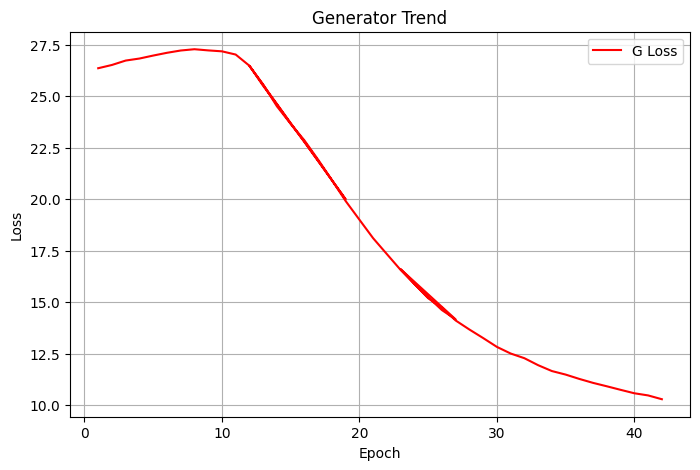

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["G_total"], label="G Loss", color='red')
plt.legend()
plt.title("Generator Trend")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

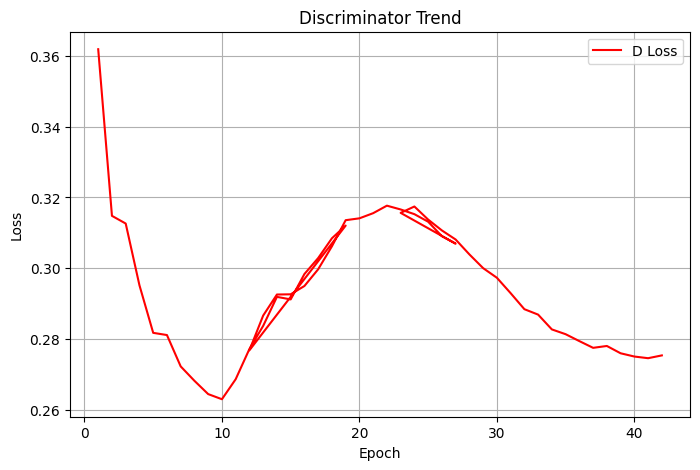

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["D_total"], label="D Loss", color='red')
plt.legend()
plt.title("Discriminator Trend")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/training_output_pix2pix/checkpoints"
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_0002.pth")
G.eval()

if os.path.exists(best_checkpoint_path):
    print(f"Loading best checkpoint from: {best_checkpoint_path}")
    ckpt = torch.load(best_checkpoint_path, map_location=device)
    G.load_state_dict(ckpt["G_state"])
    print("Generator loaded successfully!")
else:
    print("Best checkpoint not found. Please ensure training has completed and a best checkpoint exists.")


Best checkpoint not found. Please ensure training has completed and a best checkpoint exists.


In [ ]:
G.eval()
test_dataset = CTMRIDataset(SOURCE_DIR, TARGET_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    for i, (src_img, tgt_img) in enumerate(test_loader):
        src_img, tgt_img = src_img.to(device), tgt_img.to(device)


        fake_mri = G(src_img)


        break

print("Test image prepared and fake MRI generated.")


Test image prepared and fake MRI generated.


In [ ]:
from skimage.metrics import structural_similarity as sk_ssim
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
import numpy as np

ssim_score, psnr_score = compute_ssim_psnr_batch(fake_mri, tgt_img)

print(f"\nQuantitative Evaluation for the Sample:\n")
print(f"  SSIM: {ssim_score:.4f}")
print(f"  PSNR: {psnr_score:.2f} dB")



Quantitative Evaluation for the Sample:

  SSIM: 0.5456
  PSNR: 20.93 dB
